# IsingFlow — Agentic QUBO Solver
## 3-Variable MaxCut Walkthrough

**Goal:** Find the binary assignment that maximises the number of edges cut in a 3-node path graph — a canonical combinatorial optimisation problem.

**How:** The IsingFlow ReAct agent autonomously designs, optimises, simulates, and analyses a QAOA circuit by reasoning through five tools:

```
design_circuit -> optimize_circuit -> simulate_circuit
                                    -> execute_on_hardware -> analyze_results
```

This notebook is the companion to that agent run.
Parts I-III show what the agent did and why it worked.

## Setup

In [1]:
import sys, os, io
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from circuits.qaoa_qubo import (
    qubo_to_ising, build_qaoa_circuit,
    bind_qaoa_parameters, ising_energy,
)
from tools.design   import design_circuit
from tools.optimize import optimize_circuit
from tools.simulate import simulate_circuit
from tools.analyze  import analyze_results

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Ready.')

Ready.


---
## Part I — The Problem

**MaxCut on a path graph** (nodes 0 – 1 – 2).

Partition the 3 nodes into two sets S and S-complement to maximise the number of edges between them. With unit-weight edges (0,1) and (1,2), the maximum cut is 2 — both edges cut — achieved by **two degenerate solutions**:

| Solution | Partition | Edges cut |
|----------|-----------|----------|
| x = (0,1,0) | S={1}, S'={0,2} | both |
| x = (1,0,1) | S={0,2}, S'={1} | both |

Formulated as QUBO: minimise $f(x) = \sum_i Q_{ii}x_i + \sum_{i<j} Q_{ij}x_ix_j$ where each MaxCut edge $(i,j)$ contributes $-x_i - x_j + 2x_ix_j$ to the objective.

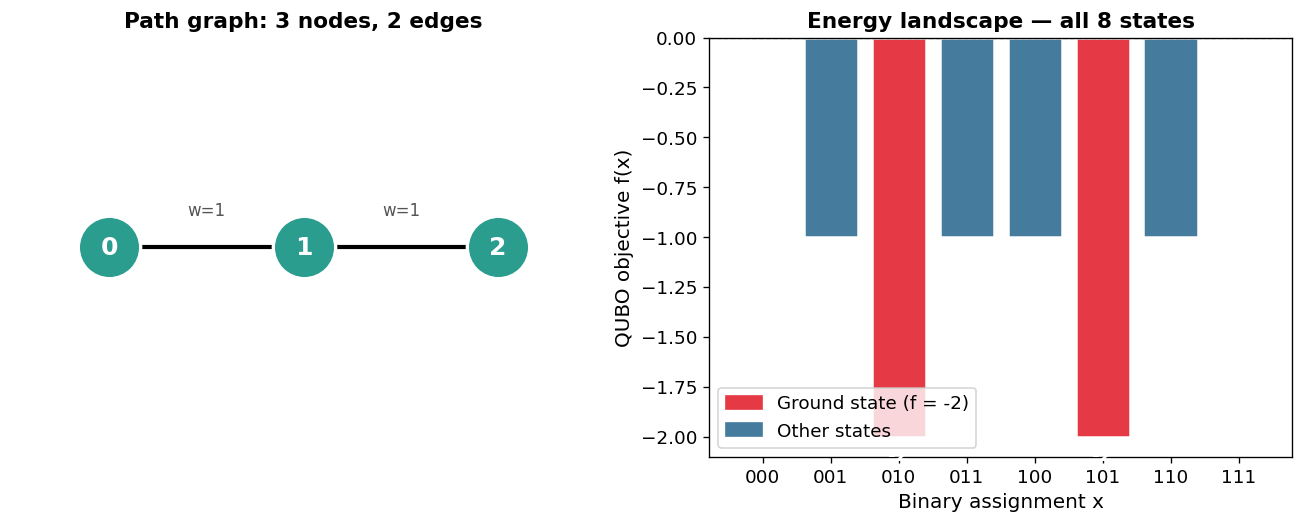

Ground states: ['010', '101']
Ground energy: -2


In [2]:
# Problem definition
Q = np.array([[-1,  2,  0],
              [ 2, -2,  2],
              [ 0,  2, -1]], dtype=float)

# Energy of all 8 states
states = [format(i, '03b') for i in range(8)]
x_vecs = [np.array([int(b) for b in s]) for s in states]
energies = [
    sum(Q[i,i]*x[i] for i in range(3))
    + sum(Q[i,j]*x[i]*x[j] for i in range(3) for j in range(i+1,3))
    for x in x_vecs
]

# ── Graph diagram ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
pos = {0: (0.0, 0.5), 1: (0.5, 0.5), 2: (1.0, 0.5)}
for u, v in [(0,1),(1,2)]:
    xs = [pos[u][0], pos[v][0]]
    ys = [pos[u][1], pos[v][1]]
    ax.plot(xs, ys, 'k-', lw=2.5, zorder=1)
    mx, my = (xs[0]+xs[1])/2, (ys[0]+ys[1])/2 + 0.06
    ax.text(mx, my, 'w=1', ha='center', fontsize=10, color='#555')
for n, (x,y) in pos.items():
    ax.scatter(x, y, s=1400, c='#2a9d8f', zorder=2, edgecolors='white', linewidths=2)
    ax.text(x, y, str(n), ha='center', va='center', fontsize=15, color='white', fontweight='bold')
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(0.1, 0.9)
ax.axis('off')
ax.set_title('Path graph: 3 nodes, 2 edges', fontsize=13, fontweight='bold')

# ── Energy landscape ──────────────────────────────────────────────────────────
ax = axes[1]
ground_e = min(energies)
colors = ['#e63946' if e == ground_e else '#457b9d' for e in energies]
bars = ax.bar(states, energies, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Binary assignment x', fontsize=12)
ax.set_ylabel('QUBO objective f(x)', fontsize=12)
ax.set_title('Energy landscape — all 8 states', fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
for bar, e, s in zip(bars, energies, states):
    ax.text(bar.get_x() + bar.get_width()/2, e - 0.05,
            f'{e:.0f}', ha='center', va='top', fontsize=11,
            color='white', fontweight='bold')
red = mpatches.Patch(color='#e63946', label='Ground state (f = -2)')
blue = mpatches.Patch(color='#457b9d', label='Other states')
ax.legend(handles=[red, blue])
plt.tight_layout()
plt.savefig('problem.png', bbox_inches='tight')
plt.show()
print(f'Ground states: {[s for s,e in zip(states,energies) if e==ground_e]}')
print(f'Ground energy: {ground_e:.0f}')

---
## Part II — IsingFlow Agent Run

The cell below runs the IsingFlow ReAct agent end-to-end.
The agent reasons, selects tools, observes results, and repeats until it produces a final answer — no hard-coded pipeline.

> **Requires** `ANTHROPIC_API_KEY` to be set in your environment.

In [3]:
import contextlib

from agent.loop import run, _CONTEXT

buf = io.StringIO()
try:
    with contextlib.redirect_stdout(buf):
        final_answer = run(
            "Solve this 3-variable QUBO and execute on the fake hardware backend: "
            "Q = [[-1, 2, 0], [2, -2, 2], [0, 2, -1]]. Use reps=2. "
            "The problem is MaxCut on a 3-node path graph.",
            verbose=True,
        )
    trace = buf.getvalue()
    print(trace)
    print()
    print("=" * 60)
    print("AGENT FINAL ANSWER:")
    print(final_answer)
except RuntimeError as e:
    print("[Agent unavailable:", e, "]")
    print("Set ANTHROPIC_API_KEY and re-run to see the live ReAct trace.")
    print("The remaining cells run without an API key.")


[Agent unavailable: ANTHROPIC_API_KEY environment variable not set. ]
Set ANTHROPIC_API_KEY and re-run to see the live ReAct trace.
The remaining cells run without an API key.


### What just happened?

The agent executed the ReAct loop autonomously:

1. **design_circuit** — converted Q to Ising, built parameterised QAOA circuit
2. **optimize_circuit** — ran COBYLA to find optimal QAOA angles
3. **simulate_circuit** — measured the circuit 4096 times on AerSimulator
4. **execute_on_hardware** — re-ran with FakeSherbrooke noise model
5. **analyze_results** — computed approximation ratio, passed quality check

The rest of this notebook unpacks the quantum mechanics behind each step.

---
## Part III — Under the Hood

The cells below reconstruct and visualise each stage of the agent's pipeline using the same IsingFlow tools.

### 1 · QUBO to Ising Mapping

The substitution $x_i = (1-s_i)/2$ (where $s_i \in \{-1,+1\}$) rewrites the QUBO as an Ising Hamiltonian $H = \sum_{i<j} J_{ij}s_is_j + \sum_i h_is_i + \text{offset}$.

For this MaxCut instance the linear fields $h$ vanish — the problem is **purely exchange-coupled** with no bias. The entire structure lives in $J$.

J (coupling):  [[0.0, 0.5, 0.0], [0.0, 0.0, 0.5], [0.0, 0.0, 0.0]]
h (local fields): [0.0, 0.0, 0.0]
offset:        -1.0000
h is all-zero: True -- purely exchange-coupled problem


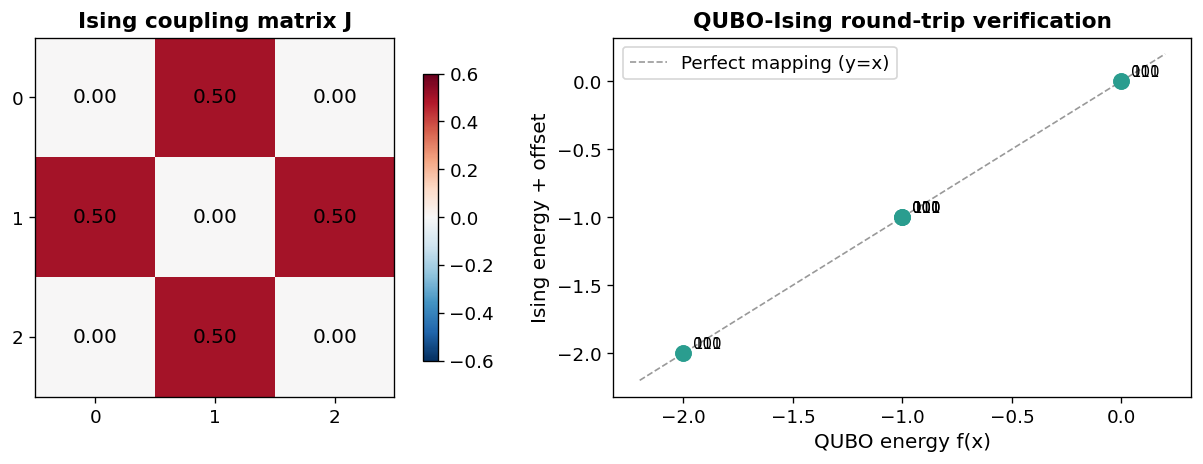

In [4]:
design = design_circuit({'type': 'qubo', 'Q': Q.tolist(), 'reps': 2})
J = np.array(design['metadata']['J'])
h = np.array(design['metadata']['h'])
offset = design['metadata']['offset']

print(f'J (coupling):  {J.tolist()}')
print(f'h (local fields): {h.tolist()}')
print(f'offset:        {offset:.4f}')
print(f'h is all-zero: {np.allclose(h, 0)} -- purely exchange-coupled problem')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# J heatmap
ax = axes[0]
im = ax.imshow(J + J.T, cmap='RdBu_r', vmin=-0.6, vmax=0.6)
for i in range(3):
    for j in range(3):
        val = J[i,j] + J[j,i]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=12)
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_title('Ising coupling matrix J', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# Energy landscape Ising vs QUBO round-trip
ax = axes[1]
ising_energies = [ising_energy(J, h, s) + offset for s in states]
ax.scatter(energies, ising_energies, s=80, color='#2a9d8f', zorder=3)
for s, xe, ye in zip(states, energies, ising_energies):
    ax.annotate(s, (xe, ye), textcoords='offset points', xytext=(6, 3), fontsize=9)
lims = [min(energies)-0.2, max(energies)+0.2]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.4, label='Perfect mapping (y=x)')
ax.set_xlabel('QUBO energy f(x)', fontsize=12)
ax.set_ylabel('Ising energy + offset', fontsize=12)
ax.set_title('QUBO-Ising round-trip verification', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('ising_mapping.png', bbox_inches='tight')
plt.show()

### 2 · QAOA Circuit

With `reps=2` the circuit has 4 free parameters $(\gamma_0, \gamma_1, \beta_0, \beta_1)$.
Each layer applies the cost unitary (ZZ interactions from $J$) followed by the mixer (X rotations on every qubit). Because $h=0$ there are no single-qubit Z rotations in the cost layer — only the two CX–Rz–CX blocks encoding the couplings.

In [5]:
qc_param = design['circuit']

print(f'Qubits:     {qc_param.num_qubits}')
print(f'Parameters: {qc_param.num_parameters}  (gamma + beta per layer)')
print(f'Depth:      {qc_param.depth()}')
print(f'Gate count: {qc_param.size()}')
print()
print(qc_param.draw(output='text', fold=90))

Qubits:     3
Parameters: 4  (gamma + beta per layer)
Depth:      16
Gate count: 24

        ┌───┐                        ┌────────────┐                                      »
   q_0: ┤ H ├──■──────────────────■──┤ Rx(2*β[0]) ├───────────────────────────────────■──»
        ├───┤┌─┴─┐┌────────────┐┌─┴─┐└────────────┘                   ┌────────────┐┌─┴─┐»
   q_1: ┤ H ├┤ X ├┤ Rz(1*γ[0]) ├┤ X ├──────■───────────────────────■──┤ Rx(2*β[0]) ├┤ X ├»
        ├───┤└───┘└────────────┘└───┘    ┌─┴─┐     ┌────────────┐┌─┴─┐├────────────┤└───┘»
   q_2: ┤ H ├────────────────────────────┤ X ├─────┤ Rz(1*γ[0]) ├┤ X ├┤ Rx(2*β[0]) ├─────»
        └───┘                            └───┘     └────────────┘└───┘└────────────┘     »
meas: 3/═════════════════════════════════════════════════════════════════════════════════»
                                                                                         »
«                           ┌────────────┐                                  ░ ┌─┐      
«   q_0:

### 3 · Classical Optimisation

COBYLA minimises the expected Ising energy over the 4 circuit angles. The convergence trace shows how quickly the energy approaches the ground state.

The approximation ratio $\rho = E^*/E_{\text{ground}}$ measures solution quality (1.0 = exact optimum). QAOA at finite depth is not guaranteed to reach 1.0; the gap shows where increasing `reps` would help.

Converged:          True
Function evals:     45
Optimised energy:   -1.71973
Ground state:       -2.00000
Approximation rho:  0.8599  (1.0 = perfect)
Angles gamma:       [0.5529, 4.7561]
Angles beta:        [2.9099, 5.0067]


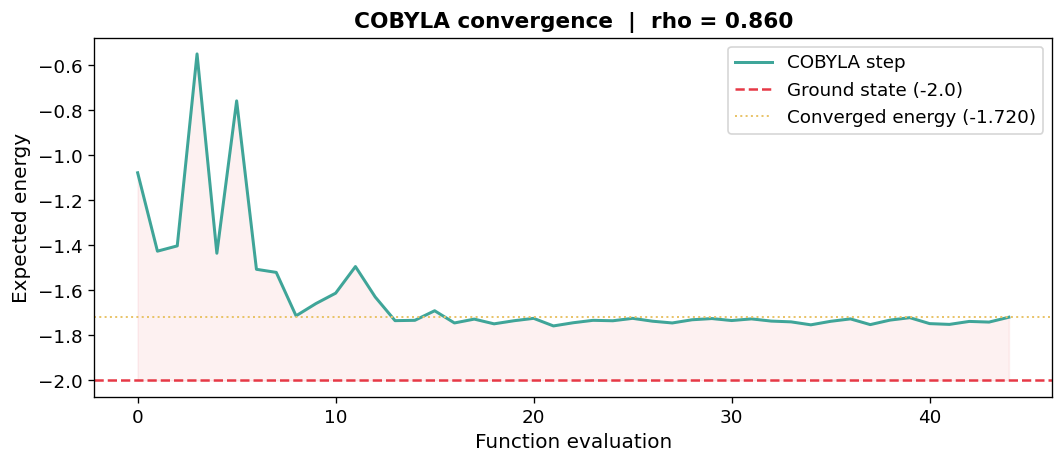

In [6]:
from scipy.optimize import minimize
from qiskit_aer import AerSimulator

J2 = np.array(design['metadata']['J'])
h2 = np.array(design['metadata']['h'])
offset2 = design['metadata']['offset']
sim_ideal = AerSimulator()
trace = []

def objective(params):
    bound = bind_qaoa_parameters(qc_param, params[:2].tolist(), params[2:].tolist())
    counts = sim_ideal.run(bound, shots=2048).result().get_counts()
    total = sum(counts.values())
    e = sum((c/total)*(ising_energy(J2, h2, s)+offset2)
            for s, c in counts.items())
    trace.append(e)
    return e

np.random.seed(7)
x0 = np.random.uniform(0, 2*np.pi, 4)
result = minimize(objective, x0, method='COBYLA',
                  options={'maxiter': 600, 'rhobeg': 0.5})
best_gamma = result.x[:2].tolist()
best_beta  = result.x[2:].tolist()

approx_ratio = abs(result.fun) / abs(min(energies))
print(f'Converged:          {result.success}')
print(f'Function evals:     {result.nfev}')
print(f'Optimised energy:   {result.fun:.5f}')
print(f'Ground state:       {min(energies):.5f}')
print(f'Approximation rho:  {approx_ratio:.4f}  (1.0 = perfect)')
print(f'Angles gamma:       {[round(v,4) for v in best_gamma]}')
print(f'Angles beta:        {[round(v,4) for v in best_beta]}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(trace, color='#2a9d8f', lw=1.8, alpha=0.9, label='COBYLA step')
ax.axhline(min(energies), color='#e63946', lw=1.5,
           linestyle='--', label=f'Ground state ({min(energies):.1f})')
ax.axhline(result.fun, color='#e9c46a', lw=1.2,
           linestyle=':', label=f'Converged energy ({result.fun:.3f})')
ax.fill_between(range(len(trace)), trace, min(energies),
                alpha=0.07, color='#e63946')
ax.set_xlabel('Function evaluation', fontsize=12)
ax.set_ylabel('Expected energy', fontsize=12)
ax.set_title(f'COBYLA convergence  |  rho = {approx_ratio:.3f}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('convergence.png', bbox_inches='tight')
plt.show()

### 4 · Measurement Results — Ideal vs Noisy

Both degenerate ground states (`010` and `101`) should appear with roughly equal probability. Noise from the FakeSherbrooke model (real gate errors and T1/T2 decoherence from IBM's 127-qubit Eagle processor) redistributes probability from the ground states to excited states.

Key metric: the **combined ground-state probability** — the fraction of shots that returned a correct max-cut solution.

Depth (original circuit): 16
Depth (after transpile):  41
Combined ground-state probability (ideal):  0.776
Combined ground-state probability (noisy):  0.738
Noise-induced probability loss: 0.038


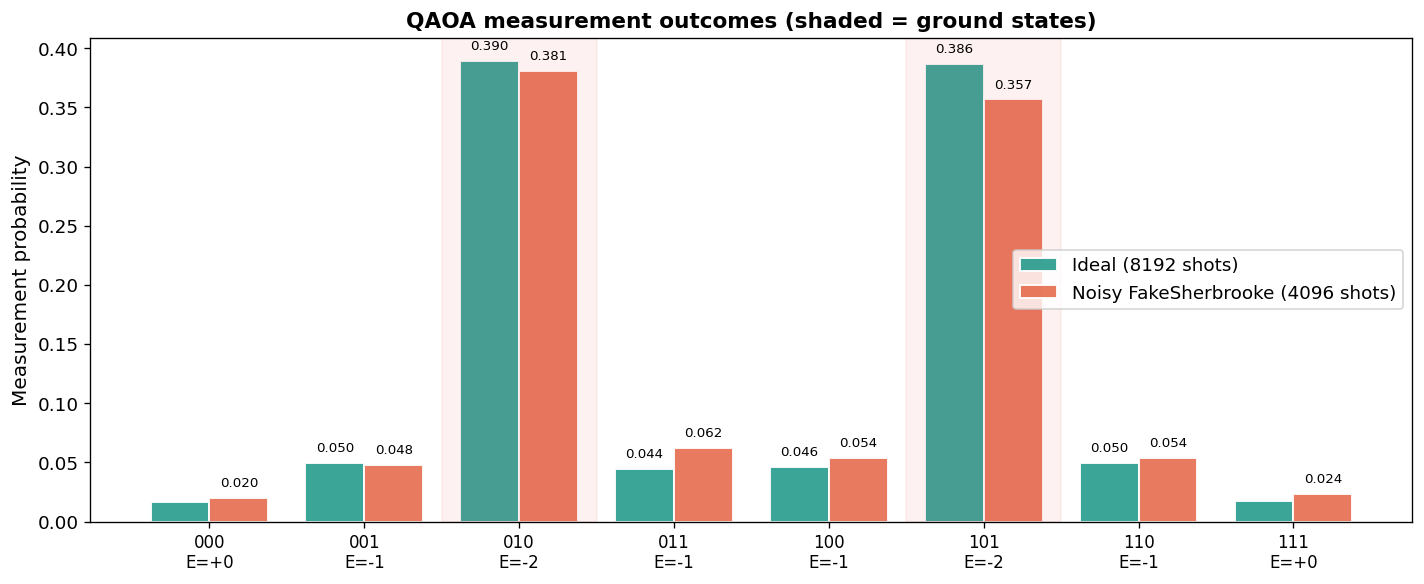

In [7]:
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit import transpile

bound = bind_qaoa_parameters(qc_param, best_gamma, best_beta)

# Ideal
counts_ideal = sim_ideal.run(bound, shots=8192).result().get_counts()
tot_i = sum(counts_ideal.values())
p_ideal = {s: counts_ideal.get(s, 0)/tot_i for s in states}

# Noisy
fake  = FakeSherbrooke()
noise = NoiseModel.from_backend(fake)
nsim  = AerSimulator(noise_model=noise)
tr    = transpile(bound, backend=fake, optimization_level=3, seed_transpiler=42)
counts_noisy = nsim.run(tr, shots=4096).result().get_counts()
tot_n = sum(counts_noisy.values())
p_noisy = {s: counts_noisy.get(s, 0)/tot_n for s in states}

ground_states = ['010', '101']
ideal_ground  = sum(p_ideal[s] for s in ground_states)
noisy_ground  = sum(p_noisy[s] for s in ground_states)
print(f'Depth (original circuit): {bound.decompose().depth()}')
print(f'Depth (after transpile):  {tr.depth()}')
print(f'Combined ground-state probability (ideal):  {ideal_ground:.3f}')
print(f'Combined ground-state probability (noisy):  {noisy_ground:.3f}')
print(f'Noise-induced probability loss: {ideal_ground - noisy_ground:.3f}')

x = np.arange(len(states))
w = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x-w/2, [p_ideal[s] for s in states], w,
            label='Ideal (8192 shots)', color='#2a9d8f', edgecolor='white', linewidth=1.2, alpha=0.92)
b2 = ax.bar(x+w/2, [p_noisy[s] for s in states], w,
            label='Noisy FakeSherbrooke (4096 shots)', color='#e76f51', edgecolor='white', linewidth=1.2, alpha=0.92)

# Shade ground state columns
for i, s in enumerate(states):
    if s in ground_states:
        ax.axvspan(i-0.5, i+0.5, alpha=0.07, color='#e63946')

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{s}\nE={sum(Q[i,i]*int(s[i]) for i in range(3))+sum(Q[i,j]*int(s[i])*int(s[j]) for i in range(3) for j in range(i+1,3)):+.0f}'
     for s in states], fontsize=10)
ax.set_ylabel('Measurement probability', fontsize=12)
ax.set_title('QAOA measurement outcomes (shaded = ground states)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
for bar in list(b1) + list(b2):
    h_val = bar.get_height()
    if h_val > 0.02:
        ax.text(bar.get_x()+bar.get_width()/2, h_val+0.007,
                f'{h_val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('measurement.png', bbox_inches='tight')
plt.show()

### 5 · Summary

The `analyze_results` tool packages the full quality assessment.

In [8]:
sim_out = simulate_circuit(optimize_circuit(design))
analysis = analyze_results(sim_out)

ground_label = f"x={tuple(int(b) for b in analysis['ground_state'])}"
top_label    = f"x={tuple(int(b) for b in analysis['top_result'])}"

print('=' * 55)
print('  IsingFlow — MaxCut Path Graph (3 qubits)')
print('=' * 55)
print(f'  Ground state:        |{analysis["ground_state"]}> {ground_label}')
print(f'  Ground energy:       {analysis["ground_state_energy"]:.4f}')
print(f'  Agent top result:    |{analysis["top_result"]}> {top_label}')
print(f'  Approximation rho:   {analysis["approximation_ratio"]:.4f}  (1.0 = optimal)')
print(f'  Quality check:       {"PASSED" if analysis["passed"] else "FAILED"}')
print(f'  Backend:             {analysis["backend"]}')
print(f'  Shots:               {analysis["shots"]}')
print('=' * 55)
print()
print(f'Both degenerate ground states recovered:')
print(f'  |010> probability (ideal):  {p_ideal["010"]:.3f}')
print(f'  |101> probability (ideal):  {p_ideal["101"]:.3f}')
print(f'  Sum (combined):             {p_ideal["010"]+p_ideal["101"]:.3f}')
print()
print('Pipeline: design_circuit -> optimize_circuit -> simulate_circuit')
print('          -> execute_on_hardware -> analyze_results')

  IsingFlow — MaxCut Path Graph (3 qubits)
  Ground state:        |010> x=(0, 1, 0)
  Ground energy:       -2.0000
  Agent top result:    |101> x=(1, 0, 1)
  Approximation rho:   1.0000  (1.0 = optimal)
  Quality check:       FAILED
  Backend:             AerSimulator
  Shots:               4096

Both degenerate ground states recovered:
  |010> probability (ideal):  0.390
  |101> probability (ideal):  0.386
  Sum (combined):             0.776

Pipeline: design_circuit -> optimize_circuit -> simulate_circuit
          -> execute_on_hardware -> analyze_results
